## Moving window tomography

This notebook allows to run moving window recontructions from a continuous tilt series. Reconstructions run on GPU using a combination of pytorch and tomosipo. The size of the window defines the maximum number of projections used for a given time step. Considering a time step i and a window w, the projections used will be [i-w/2, i+w/2]. That window will reduce at the start and end of the series so that reconstruction at time 0 uses projections [0, w/2], at time 1 [0, 1+w/2], ... at final time [i_final-w/2, i_final].

We provide routines for total variation minimization (TVM), expectation maximization (EM) and simultaneous iterative reconstruction (SIRT). The former is a custom pytorch implementation using [tomosipo's](https://github.com/cicwi/tomosipo) wrapers for differentiable back/projection. The later two are mostly reproduced from the tomosipo [algorithms](https://github.com/ahendriksen/ts_algorithms) repo.

See also: Hendriksen, Allard A., Dirk Schut, Willem Jan Palenstijn, et al. “Tomosipo: Fast, Flexible, and Convenient 3D Tomography for Complex Scanning Geometries in Python.” Optics Express 29, no. 24 (2021): 40494–513. https://doi.org/10.1364/OE.439909.


In [2]:
import torch
import numpy as np

import dipster_bare as dip
from dipster_bare.data import Sinogram, normalize
import os
from datetime import datetime
from tqdm.notebook import tqdm, trange
from skimage.transform import rotate
from kornia import losses as L
from dipster_bare import grad, util
import tomosipo as tp
import matplotlib.pyplot as plt

import stackview
from pathlib import Path

# Read Write Imports 
import mrcz
import imageio.v2 as io
import json
import mrcz

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading tiltseries

All reconstructions herein use a `ts` tiltseries as used by the dipster notebooks

In [15]:
# Read the data as tif
fname = r"C:\Users\rgirod\Data\20260611_DIPSTER\dipster_bare\data\20260811_AuAg_300_420\TiltSeries\Tomo1_AuAg_300_420_tiltSeries.tiff"
data = io.volread(fname)

# Load time and angle; this code assumes a 2 columns .csv [angles, times] and will ignore the header line
t = np.loadtxt(r"C:\Users\rgirod\Data\20260611_DIPSTER\dipster_bare\data\20260811_AuAg_300_420\TiltSeries\Angles.csv", skiprows=1, delimiter=",")
angles = t[:,0]
times = t[:,1]

print(f'Loaded a {data.shape[1:]} tilt series with {data.shape[0]} projections')
stackview.slice(data)

Loaded a (128, 128) tilt series with 81 projections


In [16]:
# The rotation axis should be horizontal as seen in stackview
# If not, run this cell
# For clarity, the series will be displayed sorted by angle, but the data to be used remain sorted by time
data = np.rot90(data, axes = (1,2))

idx = np.argsort(angles)
stackview.slice(data[idx,...])

In [17]:
# Load the data in a sinogram class
ts = Sinogram(data = data,
              angles = angles,
              times = times)

In [18]:
# Final preprocessing, and transfer to GPU
ts = normalize(ts)

# /!\ Critical point: DIP is in our matlab convention whereas stackview is in convention for napari
ts.data = np.transpose(ts.data, (1,2,0))

#convert numpy to tensor
ts.times = np.array(ts.times).astype('float64')
ts.times = (ts.times-np.min(ts.times))/(np.max(ts.times)-np.min(ts.times))
ts.data = torch.from_numpy(ts.data).to("cuda")
ts.angles =torch.from_numpy(ts.angles).to("cuda")
ts.times = torch.from_numpy(ts.times).to("cuda")

print(ts.data.shape)
print(ts.times.shape)
print(ts.angles.shape)

torch.Size([128, 128, 81])
torch.Size([81])
torch.Size([81])


## TVM reconstruction

Reconstructs a single volume from a chosen set of tilt frames by minimizing

$$\sum_f \lVert \mathrm{fp}(x,\ \theta_f) - \texttt{ts.data}[:,:,f] \rVert^2 \; + \; \lambda_{TV}\,\mathrm{TV}(x)$$

i.e. we maximize data fidelity between the reprojection and the tilt series while minimizing the
total variation of the reconstruction. It reuses dipster's differentiable
projection and uses a 3D total variation kernel. Volumes are directly optimized with Adam.

### 1. Evaluate regularization strength

The regularization weight $\lambda$ is the most important parameter here and balances between data fidelity and regularization strength. Too high will give "splotchy" results, too low will not regularize and promote adhesion to the experimental noise.

We evaluate the adequate value qualitatively by inspecting a range of results and observing the L-curve describing the size of the fidelity term vs. that of the TV term

In [43]:
# Evaluate the regularization strength
from tomo_rec import tv_reconstruct
import numpy as np

# Reconstruction parameters
LR = 0.1
TV = np.logspace(-10, -6, 20) # range of lambda values
it = 150

# Run
full_rec = np.zeros((TV.shape[0], data.shape[1], data.shape[1], data.shape[1]), dtype=np.float32)
L_data = np.zeros(TV.shape, dtype=np.float32)
L_TV = np.zeros(TV.shape, dtype=np.float32)

for i in trange(TV.shape[0]):
    # Define the range of frames used for this test
    f_min = 0
    f_max = 15
    frames = range(f_min, f_max)

    vol, data_loss, tv_loss = tv_reconstruct(ts, frames, iters=it, lr=LR, tv_weight=TV[i], nonneg=True, verbose=False)

    L_data[i] = data_loss
    L_TV[i] = tv_loss
    full_rec[i] = util.torch_to_np(vol).squeeze()

  0%|          | 0/20 [00:00<?, ?it/s]

When visualzing the results, it is apparent that noise overtakes the reconstruction at low $\lambda$ while at high values the core becomes artificially square

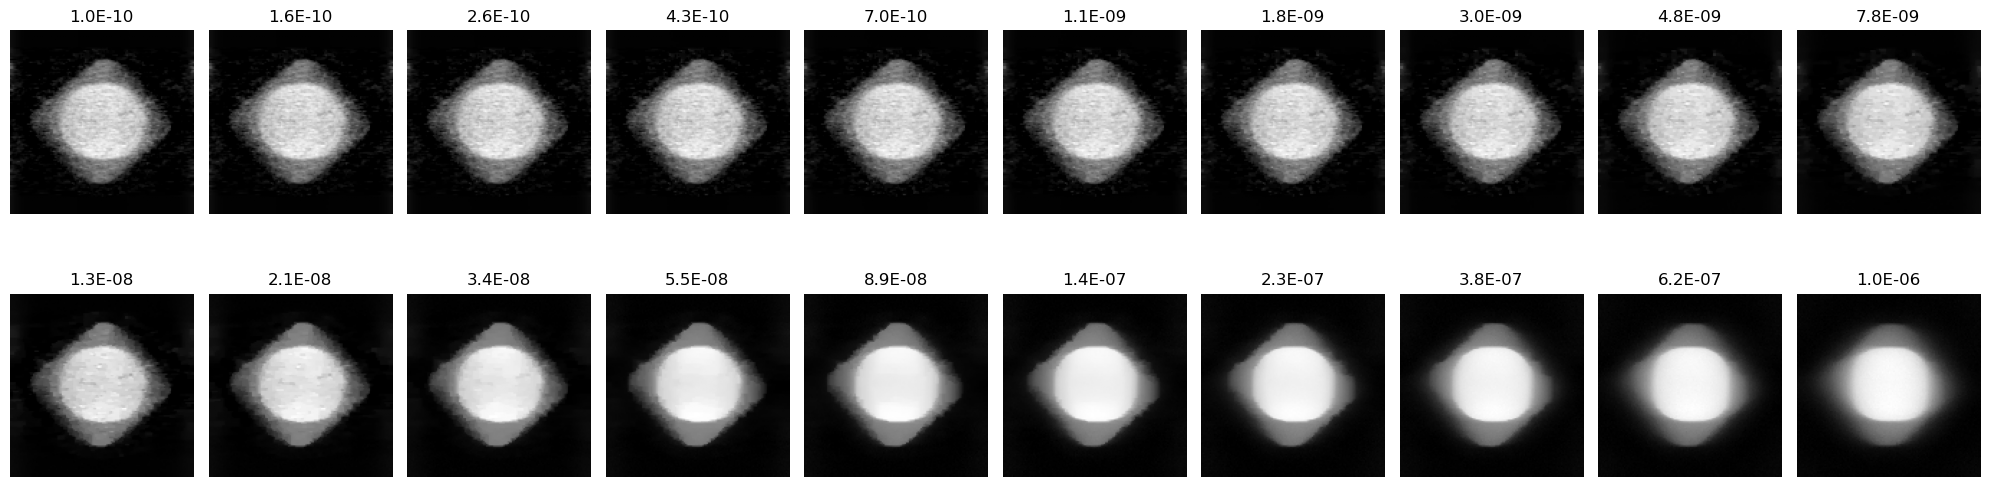

In [46]:
fig, axes = plt.subplots(max(TV.shape[0]//10, 1), min(TV.shape[0], 10), figsize = (20, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(full_rec[i, 64, :, :], cmap = 'gray')
    ax.axis('off')
    ax.set_title(f'{TV[i]:.1E}')

plt.tight_layout()
plt.show()

We can also use the L-curve to find the inflexion point at which data fidelity and TV regularization is balanced. In this example, around 2-4E-8

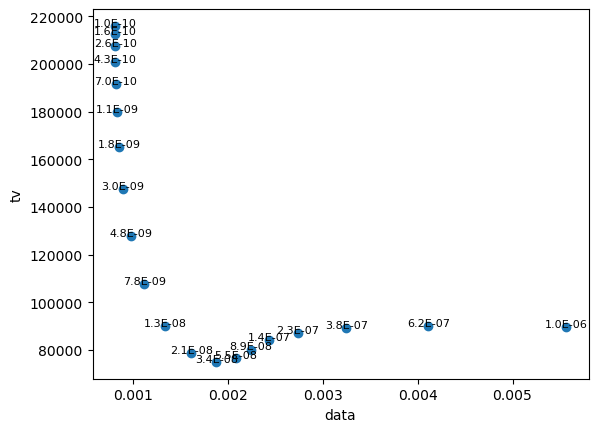

In [47]:
plt.plot(L_data, L_TV, 'o')
plt.xlabel('data')
plt.ylabel('tv')

for i, t in enumerate(TV):
    plt.text(L_data[i], L_TV[i], f'{t:.1E}', horizontalalignment='center', fontsize = 8)

plt.show()

### 2. Perform moving window reconstruction

With the desired regularization strength the full series can be reconstructed

In [48]:
from tomo_rec import tv_reconstruct

# Moving window reconstruction
window = 30
LR = 0.1
TV = 3e-8
it = 150
N = data.shape[0]

# Run
full_rec = np.zeros((data.shape[0], data.shape[1], data.shape[1], data.shape[1]), dtype=np.float32)

for i in trange(N):
    f_min = max(0, i-(window//2))
    f_max = min(data.shape[0], i+(window//2))
    frames = range(f_min, f_max)

    vol,_,_ = tv_reconstruct(ts, frames, iters=it, lr=LR, tv_weight=TV, nonneg=True, verbose=False)

    full_rec[i] = util.torch_to_np(vol).squeeze()

  0%|          | 0/81 [00:00<?, ?it/s]

In [49]:
stackview.slice(full_rec[:,:,:,64], zoom_factor=2, display_min = full_rec.min(), display_max = full_rec.max())

In [50]:
v = full_rec[-1]
stackview.orthogonal(v, zoom_factor=2, display_min = v.min(), display_max = v.max())

In [ ]:
import mrcfile

# Exports
directory = r'C:\Users\rgirod\Data\20260611_DIPSTER\dipster_bare\data\20260811_AuAg_300_420\Results' # General folder
save_dir = f'{datetime.now().strftime("%Y%m%d_%H%M")}_TVM_{it}it_{LR:.1E}lr_{TV:.1E}tv'

save_dir = os.path.join(directory, save_dir)
Path(save_dir).mkdir(parents=True, exist_ok=True)

times = ts.times.cpu().numpy()          
angles = ts.angles.cpu().numpy()        

for i, vol in tqdm(enumerate(full_rec)):
    # Save vol series
    vol = np.rot90(vol.transpose(2,1,0), 1, axes = (1,2))
    vol = np.array(vol).astype(np.float32)

    with mrcfile.new(os.path.join(save_dir, f'{i}_data_{times[i]:.3f}t_{angles[i]}deg.rec'), overwrite=True) as mrc:
        mrc.set_data(vol.astype(np.float32))
        mrc.voxel_size = 1280 # Only properly read by Amira / Avizo
        mrc.update_header_from_data()

0it [00:00, ?it/s]

## EM reconstruction

In [51]:
from tomo_rec import em

# Moving window reconstruction
window = 30
it = 25
N = data.shape[0] # N frames

# Run
full_rec = np.zeros((data.shape[0], data.shape[1], data.shape[1], data.shape[1]), dtype=np.float32)

for i in trange(N):
    f_min = max(0, i-(window//2))
    f_max = min(data.shape[0], i+(window//2))
    frames = range(f_min, f_max)

    P = ts.data.shape[0]
    angs = (np.asarray(util.torch_to_np(angles[frames]), dtype=float) + 90) * np.pi / 180
    pg = tp.parallel(angles=angs, shape=(P, P), size=(1, 1))
    vg = tp.volume(shape=(P, P, P), size=(1, 1, 1))
    A = tp.operator(vg, pg)

    # Rec
    y = ts.data[..., frames].permute(1, 2, 0).contiguous()      # [depth, N, det]  
    vol = em(A, y, it, x_init=None, volume_mask=None,
    projection_mask=None, progress_bar=False)

    full_rec[i] = util.torch_to_np(vol.permute(1, 0, 2)).squeeze()

  0%|          | 0/81 [00:00<?, ?it/s]

In [52]:
stackview.slice(full_rec[:,:,:,64], zoom_factor=2, display_min = full_rec.min(), display_max = full_rec.max())

In [53]:
v = full_rec[0]
stackview.orthogonal(v, zoom_factor=2, display_min = v.min(), display_max = v.max())

In [ ]:
# Exports
import mrcfile
directory = r'C:\Users\rgirod\Data\20260611_DIPSTER\dipster_bare\data\20260811_AuAg_300_420\Results' # General folder
save_dir = f'{datetime.now().strftime("%Y%m%d_%H%M")}_EM_{it}it'

save_dir = os.path.join(directory, save_dir)
Path(save_dir).mkdir(parents=True, exist_ok=True)

times = ts.times.cpu().numpy()          
angles = ts.angles.cpu().numpy()        

for i, vol in tqdm(enumerate(full_rec)):
    # Save vol series
    vol = np.rot90(vol.transpose(2,1,0), 1, axes = (1,2))
    vol = np.array(vol).astype(np.float32)

    with mrcfile.new(os.path.join(save_dir, f'{i}_data_{times[i]:.3f}t_{angles[i]}deg.rec'), overwrite=True) as mrc:
        mrc.set_data(vol.astype(np.float32))
        mrc.voxel_size = 1280 # Only properly read by Amira / Avizo
        mrc.update_header_from_data()

0it [00:00, ?it/s]

# SIRT reconstruction

In [54]:
from tomo_rec import sirt

# Moving window reconstruction
window = 30
it = 100
N = data.shape[0] # N frames

# Run
full_rec = np.zeros((data.shape[0], data.shape[1], data.shape[1], data.shape[1]), dtype=np.float32)

for i in trange(N):
    f_min = max(0, i-(window//2))
    f_max = min(data.shape[0], i+(window//2))
    frames = range(f_min, f_max)

    P = ts.data.shape[0]
    angs = (np.asarray(util.torch_to_np(angles[frames]), dtype=float) + 90) * np.pi / 180
    pg = tp.parallel(angles=angs, shape=(P, P), size=(1, 1))
    vg = tp.volume(shape=(P, P, P), size=(1, 1, 1))
    A = tp.operator(vg, pg)

    # Rec
    y = ts.data[..., frames].permute(1, 2, 0).contiguous()      # [depth, N, det]  
    vol = sirt(A, y, it, x_init=None, volume_mask=None,
    projection_mask=None, progress_bar=False, min_constraint=0)

    full_rec[i] = util.torch_to_np(vol.permute(1, 0, 2)).squeeze()

  0%|          | 0/81 [00:00<?, ?it/s]

In [55]:
v = full_rec[0]
stackview.orthogonal(v, zoom_factor=2, display_min = v.min(), display_max = v.max())

In [ ]:
# Exports
import mrcfile
directory = r'C:\Users\rgirod\Data\20260611_DIPSTER\dipster_bare\data\20260811_AuAg_300_420\Results' # General folder
save_dir = f'{datetime.now().strftime("%Y%m%d_%H%M")}_SIRT_{it}it'

save_dir = os.path.join(directory, save_dir)
Path(save_dir).mkdir(parents=True, exist_ok=True)

times = ts.times.cpu().numpy()          
angles = ts.angles.cpu().numpy()        

for i, vol in tqdm(enumerate(full_rec)):
    # Save vol series
    vol = np.rot90(vol.transpose(2,1,0), 1, axes = (1,2))
    vol = np.array(vol).astype(np.float32)

    with mrcfile.new(os.path.join(save_dir, f'{i}_data_{times[i]:.3f}t_{angles[i]}deg.rec'), overwrite=True) as mrc:
        mrc.set_data(vol.astype(np.float32))
        mrc.voxel_size = 1280 # Only properly read by Amira / Avizo
        mrc.update_header_from_data()

0it [00:00, ?it/s]